## RNN Model Building LSTM (Long Short-Term Memory)

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import edf

original_df, X_train_raw, X_val_raw, X_test_raw, Y_train_raw, Y_val_raw, Y_test_raw = edf.get_data_for_modeling()

In [25]:
# Prepare the data for LSTM model (Multivariate)
features = original_df.columns.tolist()
target = 'Demand'
feature_cols = [c for c in features if c != target]

data = original_df[feature_cols + [target]].values
training_data_len = int(np.ceil(len(data) * 0.8))

# Preprocessing: Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

train_data = scaled_data[0:len(X_train_raw), :]
val_data = scaled_data[len(X_train_raw):len(X_train_raw)+len(X_val_raw), :]

X_train = []
Y_train = []
X_val = []
Y_val = []

# Create a sliding window of 24 hours to predict the next hour's demand
window_size = 24
for i in range(window_size, len(train_data)):
    X_train.append(train_data[i-window_size:i, :-1]) # All columns except last (target)
    Y_train.append(train_data[i, -1])     # Last column (target)

# For validation, we need the last 24 hours of training data to predict the first hour of validation
combined_train_val = np.vstack([train_data[-window_size:], val_data])
for i in range(window_size, len(combined_train_val)):
    X_val.append(combined_train_val[i-window_size:i, :-1])
    Y_val.append(combined_train_val[i, -1])

X_train, Y_train = np.array(X_train), np.array(Y_train)
X_val, Y_val = np.array(X_val), np.array(Y_val)
# X_train shape: (samples, time_steps, features)

In [26]:
# Building the LSTM model
model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2])),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.LSTM(64, return_sequences=False),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

# Building the LSTM model
model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2])),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.LSTM(64, return_sequences=False),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

early_stop = EarlyStopping(
    monitor='val_loss',        # metric to watch
    patience=10,                # stop after 10 epochs of no improvement
    restore_best_weights=True  # revert to best epoch weights
)

model.summary()
model.compile(optimizer='adam', loss='mae', metrics=[keras.metrics.RootMeanSquaredError()])

history = model.fit(X_train, Y_train, epochs=20, batch_size=32, validation_data=(X_val, Y_val), callbacks=[early_stop])

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                  │ (None, 24, 64)         │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_33 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,169 (278.00 KB)

 Trainable params: 71,169 (278.00 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 213,509 (834.02 KB)

 Trainable params: 71,169 (278.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 142,340 (556.02 KB)

Epoch 1/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 60s 36ms/step - loss: 0.1109 - root_mean_squared_error: 0.1426 - val_loss: 0.1033 - val_root_mean_squared_error: 0.1318
Epoch 2/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - loss: 0.1100 - root_mean_squared_error: 0.1414 - val_loss: 0.1051 - val_root_mean_squared_error: 0.1326
Epoch 3/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 36s 33ms/step - loss: 0.1098 - root_mean_squared_error: 0.1413 - val_loss: 0.1065 - val_root_mean_squared_error: 0.1364
Epoch 4/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - loss: 0.1092 - root_mean_squared_error: 0.1405 - val_loss: 0.1067 - val_root_mean_squared_error: 0.1347
Epoch 5/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - loss: 0.1095 - root_mean_squared_error: 0.1407 - val_loss: 0.1182 - val_root_mean_squared_error: 0.1491
Epoch 6/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - loss: 0.1089 - root_mean_squared_error: 0.1400 - val_loss: 0.1078 - val_root_mean_squared_error: 0.1356
Epoch 7/20
1081/1081 ━━━━━━━

In [27]:
# Prepare the test data
test_data = scaled_data[training_data_len - 24:, :]
X_test = []
Y_actual = original_df[target].values[training_data_len:]
Y_actual = Y_actual.reshape(-1, 1)

for i in range(24, len(test_data)):
    X_test.append(test_data[i-24:i, :-1])

X_test = np.array(X_test)

# Make predictions
predictions = model.predict(X_test)

# To inverse transform the prediction, we need to provide the same shape as scaled_data
# We'll create a dummy array for this purpose
dummy = np.zeros((len(predictions), data.shape[1]))
dummy[:, -1] = predictions.flatten()
inverse = scaler.inverse_transform(dummy)
predictions = inverse[:, -1].reshape(-1, 1)

# Evaluating the LSTM model
mae_lstm = mean_absolute_error(Y_actual, predictions)
rmse_lstm = np.sqrt(mean_squared_error(Y_actual, predictions))
r2_lstm = r2_score(Y_actual, predictions)
mape_lstm = np.mean(np.abs((Y_actual - predictions) / Y_actual)) * 100
mne_lstm = np.mean(edf.calculate_normalized_error(Y_actual, predictions.flatten()))

print('LSTM RMSE:', rmse_lstm)
print('LSTM MAE:', mae_lstm)
print('LSTM R^2 Score (Accuracy):', r2_lstm)
print(f'LSTM MAPE: {mape_lstm:.2f}%')
print(f'LSTM Mean Normalized Error (0-1): {mne_lstm:.4f}')

# Calculate Confidence Interval (95%)
residuals = Y_actual - predictions
std_residuals = np.std(residuals)
confidence_interval = 1.96 * std_residuals
print(f'LSTM 95% Confidence Interval: +/- {confidence_interval:.2f}')

273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
LSTM RMSE: 215.4946016556648
LSTM MAE: 161.39945112757817
LSTM R^2 Score (Accuracy): 0.9767240892779033
LSTM MAPE: 3.39%
LSTM Mean Normalized Error (0-1): 0.1628
LSTM 95% Confidence Interval: +/- 421.13


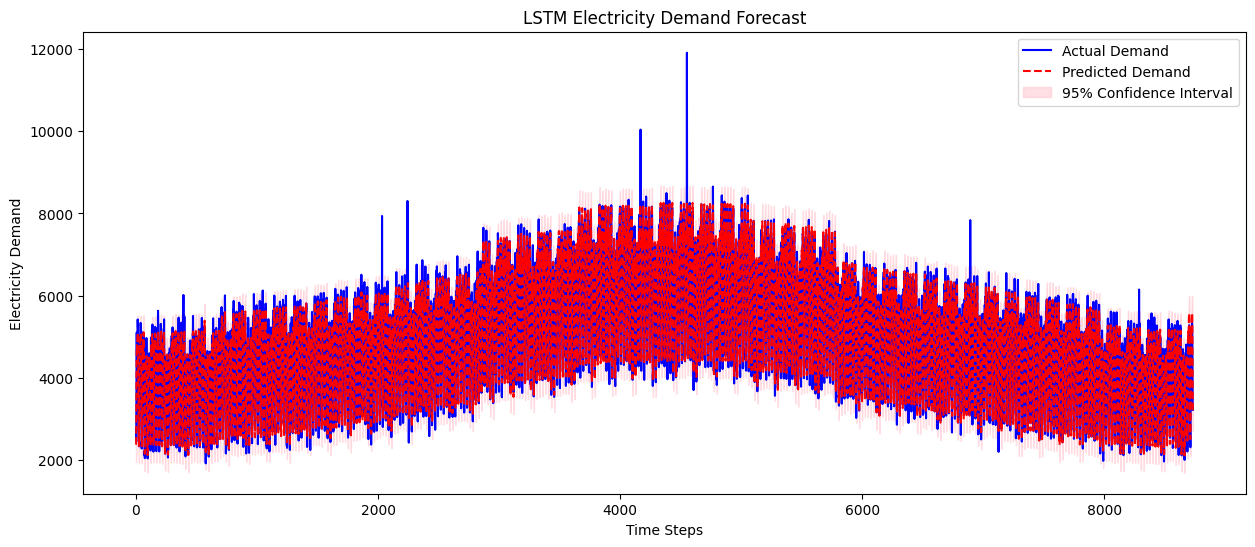

In [28]:
# Visualize the predictions vs actual values
plt.figure(figsize=(15,6))
plt.plot(range(len(Y_actual)), Y_actual, label='Actual Demand', color='blue')
plt.plot(range(len(predictions)), predictions, label='Predicted Demand', color='Red', linestyle='--')
plt.fill_between(range(len(predictions)), 
                 (predictions.flatten() - confidence_interval), 
                 (predictions.flatten() + confidence_interval), 
                 color='pink', alpha=0.5, label='95% Confidence Interval')
plt.title("LSTM Electricity Demand Forecast")
plt.xlabel("Time Steps")
plt.ylabel("Electricity Demand")
plt.legend()
plt.show()